# NB01 — Exploratory Data Analysis

**Question:** Are the cleaned tables from NB00 trustworthy enough to model on? Specifically: is panel coverage uniform, are labels balanced, is there a real post-call price reaction, and does equal-weight already beat SPY (i.e. how high is the bar)?

## Pipeline

```
NB00 → data/clean/{earnings_sessions, earnings_segments, prices, labels}.parquet
                              │
NB01 (this notebook, read-only — produces no parquet, only figures):
   1. Coverage matrix        — 50 companies × 8 years heatmap (target = 4 calls/year)
   2. Transcript structure   — segment-type mix + length by sector (motivates NB02 chunking)
   3. Label distribution     — overall ~50/50, year-by-year regime variation
   4. Train/Val/Test split   — visualise 2018–22 / 2023 / 2024 / 2025 partition
   5. Cumulative returns     — 50 names vs SPY (selection effect)
   6. Volatility profile     — annualised vol by ticker, sector-coloured
   7. Event study T−5..T+15  — validates the 10-day label captures real PEAD
   8. Naive equal-weight     — the bar NB05 must clear (not SPY)
```

**Why this matters for downstream notebooks:**
- §2 → motivates NB02's per-segment chunking (median ~14 k tokens won't fit one prompt)
- §3 → justifies NB04's separate test-bull (2024) vs test-volatile (2025) split
- §7 → confirms `LABEL_HOLDING_DAYS = 10` captures the PEAD signal NB04 tries to predict
- §8 → sets the **comparator floor** for NB05 (BuyHold_EW50, not SPY)

NB01 writes nothing back to `data/`; it is a pure quality-check notebook.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.llm_agent.data_loader import load_segments, load_sessions, load_labels, load_prices

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
pd.set_option('display.max_colwidth', 120)

In [2]:
segments = load_segments()
sessions = load_sessions()
labels = load_labels()
prices = load_prices()

if prices['date'].dtype == 'object':
    prices['date'] = pd.to_datetime(prices['date'])
if labels['event_date'].dtype == 'object':
    labels['event_date'] = pd.to_datetime(labels['event_date'])

SECTOR_MAP = {
    **{t: 'IT'         for t in ['AAPL','MSFT','NVDA','AVGO','ORCL','CRM','ADBE','NOW']},
    **{t: 'Comm'       for t in ['GOOGL','META','NFLX','DIS','TMUS']},
    **{t: 'Cons Disc'  for t in ['LOW','TSLA','HD','MCD','NKE','SBUX','CMG']},
    **{t: 'Cons Stap'  for t in ['WMT','PG','KO','COST']},
    **{t: 'Health'     for t in ['UNH','JNJ','LLY','PFE','ABBV','MRK']},
    **{t: 'Financial'  for t in ['JPM','BAC','WFC','GS','MS','SCHW','V']},
    **{t: 'Industrial' for t in ['CAT','BA','HON','UPS']},
    **{t: 'Energy'     for t in ['XOM','CVX','COP']},
    **{t: 'Utility'    for t in ['SO','DUK']},
    **{t: 'Real Est'   for t in ['PLD','AMT']},
    **{t: 'Materials'  for t in ['LIN','SHW']},
}

print(f'Sessions:  {len(sessions):>6,}  ({sessions.ticker.nunique()} companies)')
print(f'Segments:  {len(segments):>6,}  (avg {len(segments)/len(sessions):.0f} per session)')
print(f'Labels:    {len(labels):>6,}  (positive rate: {labels.label.mean():.1%})')
print(f'Prices:    {len(prices):>6,}  ({prices.ticker.nunique()} tickers including SPY)')

Sessions:   1,520  (50 companies)
Segments:  94,324  (avg 62 per session)
Labels:     1,520  (positive rate: 50.7%)
Prices:    109,650  (51 tickers including SPY)


## 1. Coverage matrix

Confirms our 50-company × 8-year panel is well-covered (target = 4 calls per company per year).

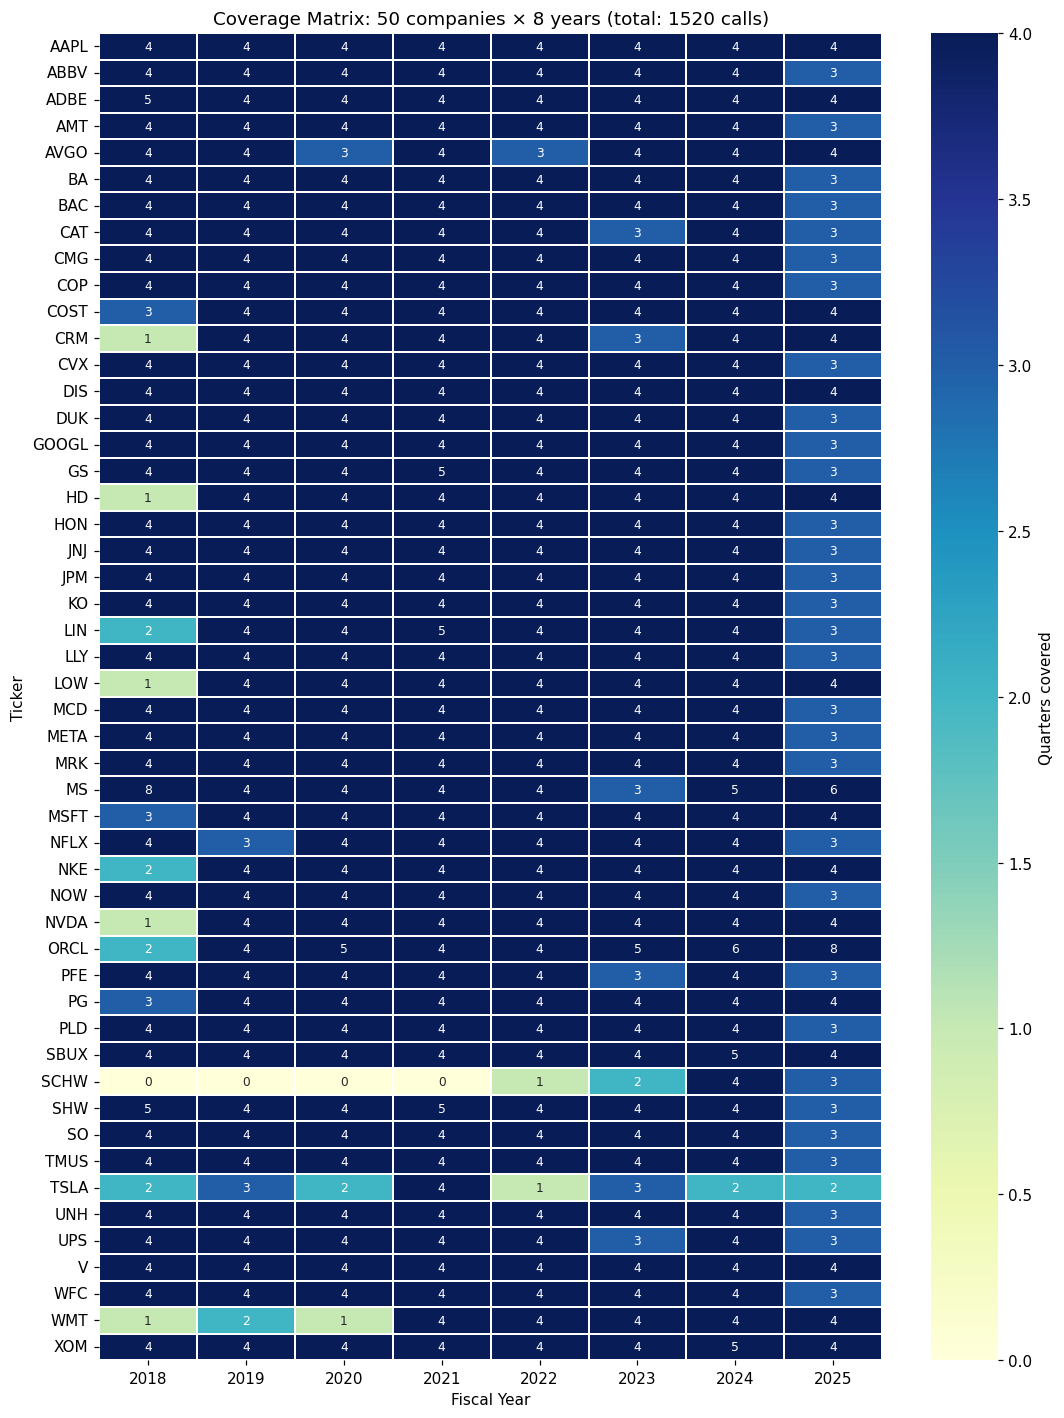


>= 90% coverage: 46 / 50
65-90% coverage: 2
< 65% coverage : 2


In [3]:
pivot = sessions.groupby(['ticker', 'fiscal_year']).size().unstack(fill_value=0).sort_index()

fig, ax = plt.subplots(figsize=(10, 13))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu',
            cbar_kws={'label': 'Quarters covered'}, linewidths=0.3,
            vmin=0, vmax=4, ax=ax, annot_kws={'size': 8})
ax.set_title(f'Coverage Matrix: {pivot.shape[0]} companies × {pivot.shape[1]} years '
             f'(total: {sessions.shape[0]} calls)')
ax.set_xlabel('Fiscal Year'); ax.set_ylabel('Ticker')
plt.tight_layout(); plt.show()

expected = 32
rate = pivot.sum(axis=1) / expected
print(f'\n>= 90% coverage: {(rate >= 0.9).sum()} / {len(rate)}')
print(f'65-90% coverage: {((rate >= 0.65) & (rate < 0.9)).sum()}')
print(f'< 65% coverage : {(rate < 0.65).sum()}')

## 2. Transcript structure

A typical earnings call has two distinct parts. The LLM signals we extract differ by part:
- **Prepared remarks** — scripted; compare to prior quarters via RAG (what is *not* said)
- **Q&A** — extemporaneous; score certainty / evasion in management answers

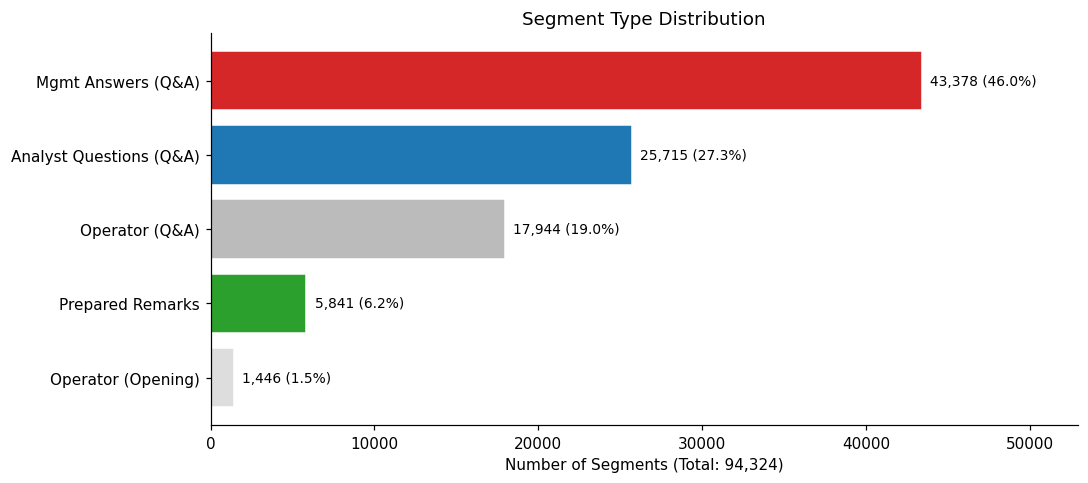

In [4]:
type_counts = segments.componenttypename.value_counts()
type_labels = {
    'Answer':                                 'Mgmt Answers (Q&A)',
    'Question':                               'Analyst Questions (Q&A)',
    'Question and Answer Operator Message':   'Operator (Q&A)',
    'Presenter Speech':                       'Prepared Remarks',
    'Presentation Operator Message':          'Operator (Opening)',
}
type_counts.index = [type_labels.get(t, t) for t in type_counts.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#d62728', '#1f77b4', '#bbbbbb', '#2ca02c', '#dddddd']
bars = ax.barh(type_counts.index, type_counts.values, color=colors, edgecolor='white')
for bar, v in zip(bars, type_counts.values):
    ax.text(v + 500, bar.get_y() + bar.get_height()/2,
            f'{v:,} ({v/type_counts.sum()*100:.1f}%)', va='center', fontsize=9)
ax.set_xlabel(f'Number of Segments (Total: {type_counts.sum():,})')
ax.set_title('Segment Type Distribution')
ax.set_xlim(0, type_counts.max() * 1.22)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

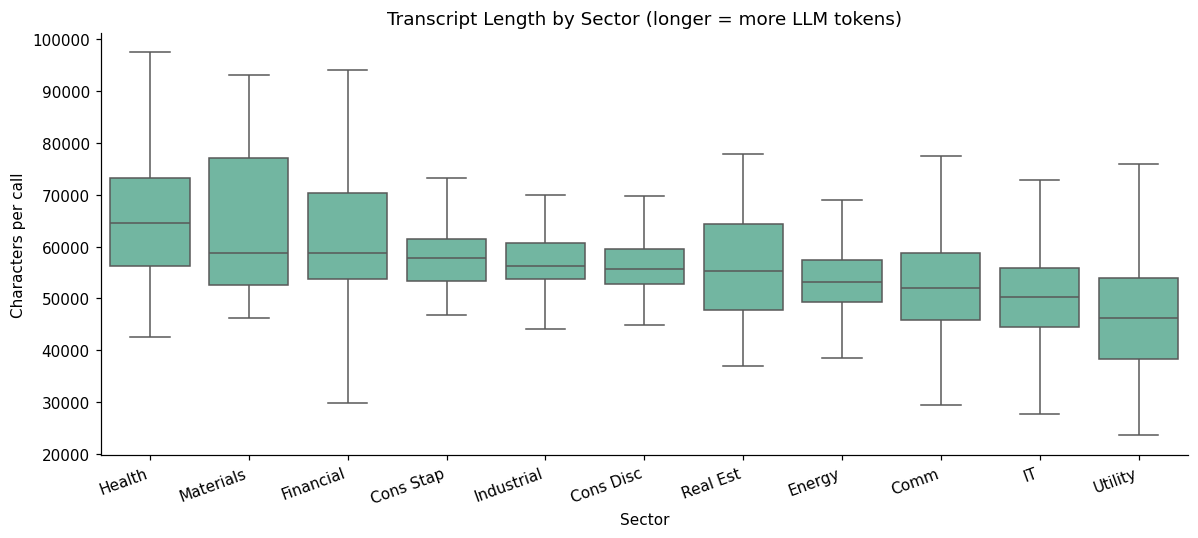

Median: 55,666 chars (~13917 GPT-4 tokens)
95th  : 78,813 chars
 5th  : 37,455 chars


In [5]:
session_lengths = sessions.copy()
session_lengths['sector'] = session_lengths['ticker'].map(SECTOR_MAP)

fig, ax = plt.subplots(figsize=(11, 5))
order = (session_lengths.groupby('sector')['n_chars'].median()
         .sort_values(ascending=False).index.tolist())
sns.boxplot(data=session_lengths, x='sector', y='n_chars',
            order=order, ax=ax, showfliers=False)
ax.set_title('Transcript Length by Sector (longer = more LLM tokens)')
ax.set_xlabel('Sector'); ax.set_ylabel('Characters per call')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

med = sessions.n_chars.median()
print(f'Median: {med:,.0f} chars (~{med/4:.0f} GPT-4 tokens)')
print(f'95th  : {sessions.n_chars.quantile(0.95):,.0f} chars')
print(f' 5th  : {sessions.n_chars.quantile(0.05):,.0f} chars')

**Implication.** Median ~14 k tokens — too long for a single Claude prompt.
We chunk by speaker turns and treat prepared / Q&A separately in NB2.

## 3. Label distribution + yearly regimes

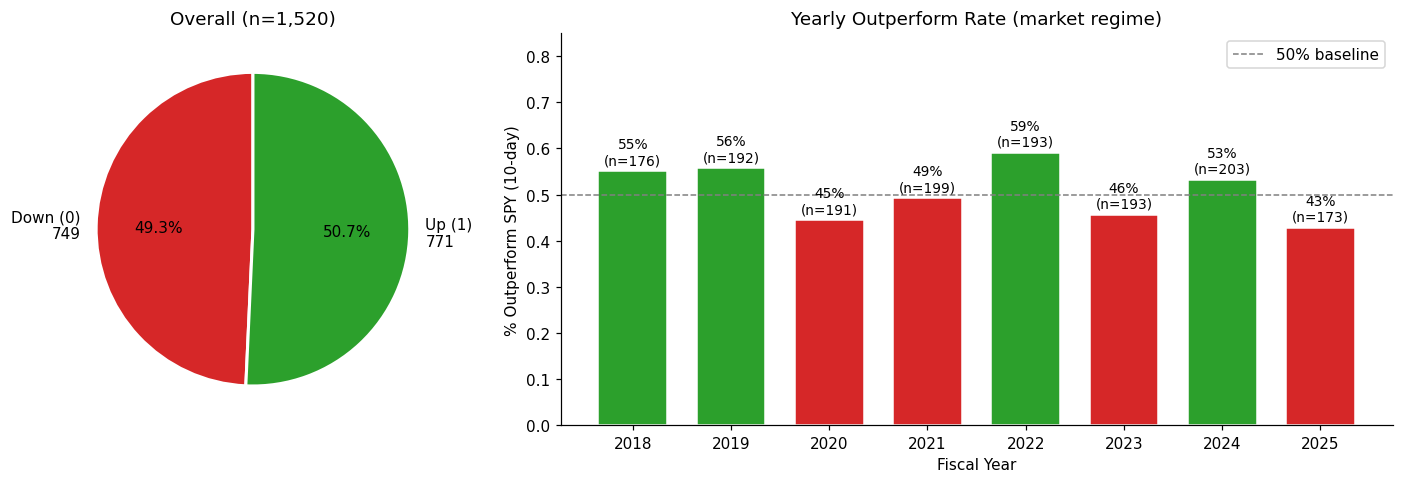

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5),
                                gridspec_kw={'width_ratios': [1, 2]})

total = labels['label'].value_counts().sort_index()
ax1.pie(total.values,
        labels=[f'Down (0)\n{int(total[0]):,}', f'Up (1)\n{int(total[1]):,}'],
        colors=['#d62728', '#2ca02c'], autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title(f'Overall (n={len(labels):,})')

yearly = (labels.dropna(subset=['label']).groupby('fiscal_year')['label']
          .agg(['mean', 'count']).reset_index())
bars = ax2.bar(yearly['fiscal_year'].astype(str), yearly['mean'],
               color=['#2ca02c' if v >= 0.5 else '#d62728' for v in yearly['mean']],
               edgecolor='white', width=0.7)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% baseline')
ax2.set_xlabel('Fiscal Year'); ax2.set_ylabel('% Outperform SPY (10-day)')
ax2.set_title('Yearly Outperform Rate (market regime)')
ax2.legend(loc='upper right'); ax2.set_ylim(0, 0.85)
for bar, (_, row) in zip(bars, yearly.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f'{row["mean"]:.0%}\n(n={int(row["count"])})', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

Class balance is healthy (~50/50). Year-by-year variation justifies splitting test
into 2024 (bull) and 2025 (volatile).

## 4. Train / Val / Test split

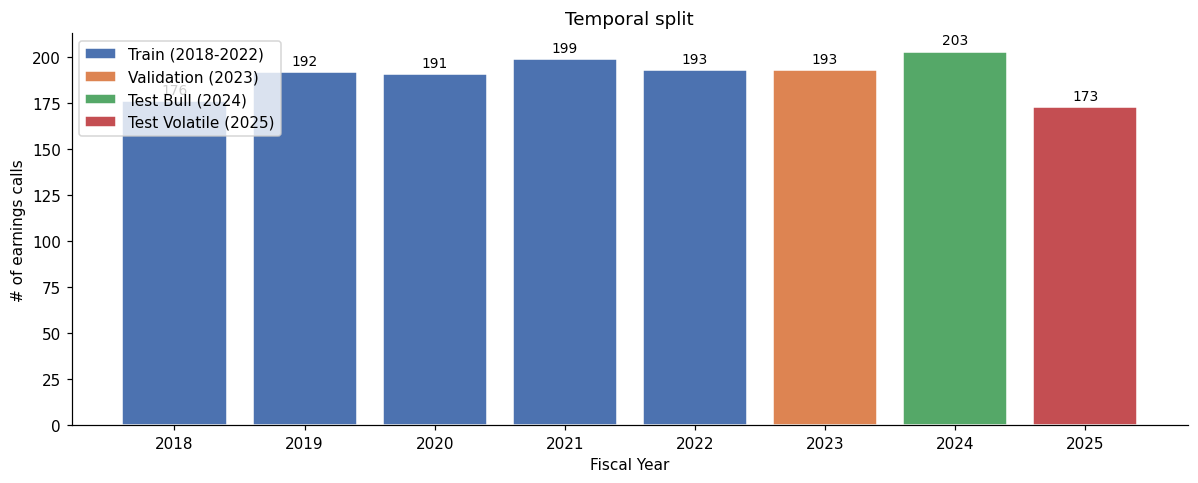

In [7]:
counts_by_year = sessions.groupby('fiscal_year').size()

def get_period(y):
    if 2018 <= y <= 2022: return 'Train (2018-2022)'
    if y == 2023:         return 'Validation (2023)'
    if y == 2024:         return 'Test Bull (2024)'
    if y == 2025:         return 'Test Volatile (2025)'
    return 'Other'

period_colors = {'Train (2018-2022)': '#4c72b0', 'Validation (2023)': '#dd8452',
                 'Test Bull (2024)':  '#55a868', 'Test Volatile (2025)': '#c44e52'}

fig, ax = plt.subplots(figsize=(11, 4.5))
labeled = set()
for year, count in counts_by_year.items():
    p = get_period(year)
    ax.bar(str(year), count, color=period_colors.get(p, '#888'),
           edgecolor='white', label=p if p not in labeled else '')
    labeled.add(p)
    ax.text(str(year), count + 4, str(count), ha='center', fontsize=9)
ax.set_xlabel('Fiscal Year'); ax.set_ylabel('# of earnings calls')
ax.set_title('Temporal split')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

## 5. Cumulative returns (50 stocks vs SPY)

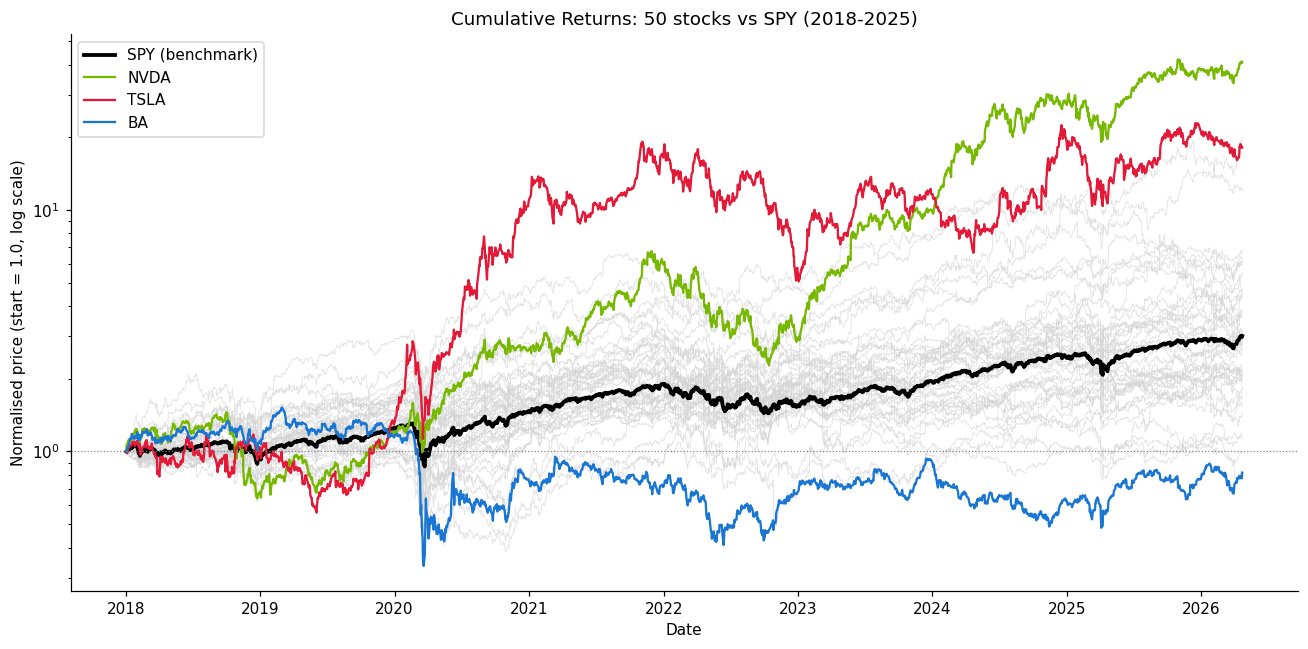


Top 5:
  NVDA    +4009%
  AVGO    +1904%
  TSLA    +1713%
  LLY     +1128%
  AAPL    +578%
Bottom 5:
  UPS     +17%
  PFE     +12%
  DIS     -1%
  BA      -18%
  NKE     -20%


[None, None, None, None, None]

In [8]:
price_col = 'adj_close' if 'adj_close' in prices.columns else 'close'
pivot_px = prices.pivot(index='date', columns='ticker', values=price_col).loc['2018-01-01':]
norm = pivot_px / pivot_px.iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))
for col in norm.columns:
    if col == 'SPY': continue
    ax.plot(norm.index, norm[col], color='lightgray', linewidth=0.6, alpha=0.6)
for ticker, color, lw, label in [
    ('SPY', '#000000', 2.5, 'SPY (benchmark)'),
    ('NVDA', '#76B900', 1.5, 'NVDA'),
    ('TSLA', '#E31937', 1.5, 'TSLA'),
    ('BA',   '#1976D2', 1.5, 'BA'),
]:
    if ticker in norm.columns:
        ax.plot(norm.index, norm[ticker], color=color, linewidth=lw, label=label)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Date'); ax.set_ylabel('Normalised price (start = 1.0, log scale)')
ax.set_title('Cumulative Returns: 50 stocks vs SPY (2018-2025)')
ax.legend(loc='upper left'); ax.set_yscale('log')
plt.tight_layout(); plt.show()

final = (norm.iloc[-1] - 1).sort_values(ascending=False)
print('\nTop 5:'); [print(f'  {t:6s}  {r:+.0%}') for t, r in final.head(5).items()]
print('Bottom 5:'); [print(f'  {t:6s}  {r:+.0%}') for t, r in final.tail(5).items()]

## 6. Volatility profile

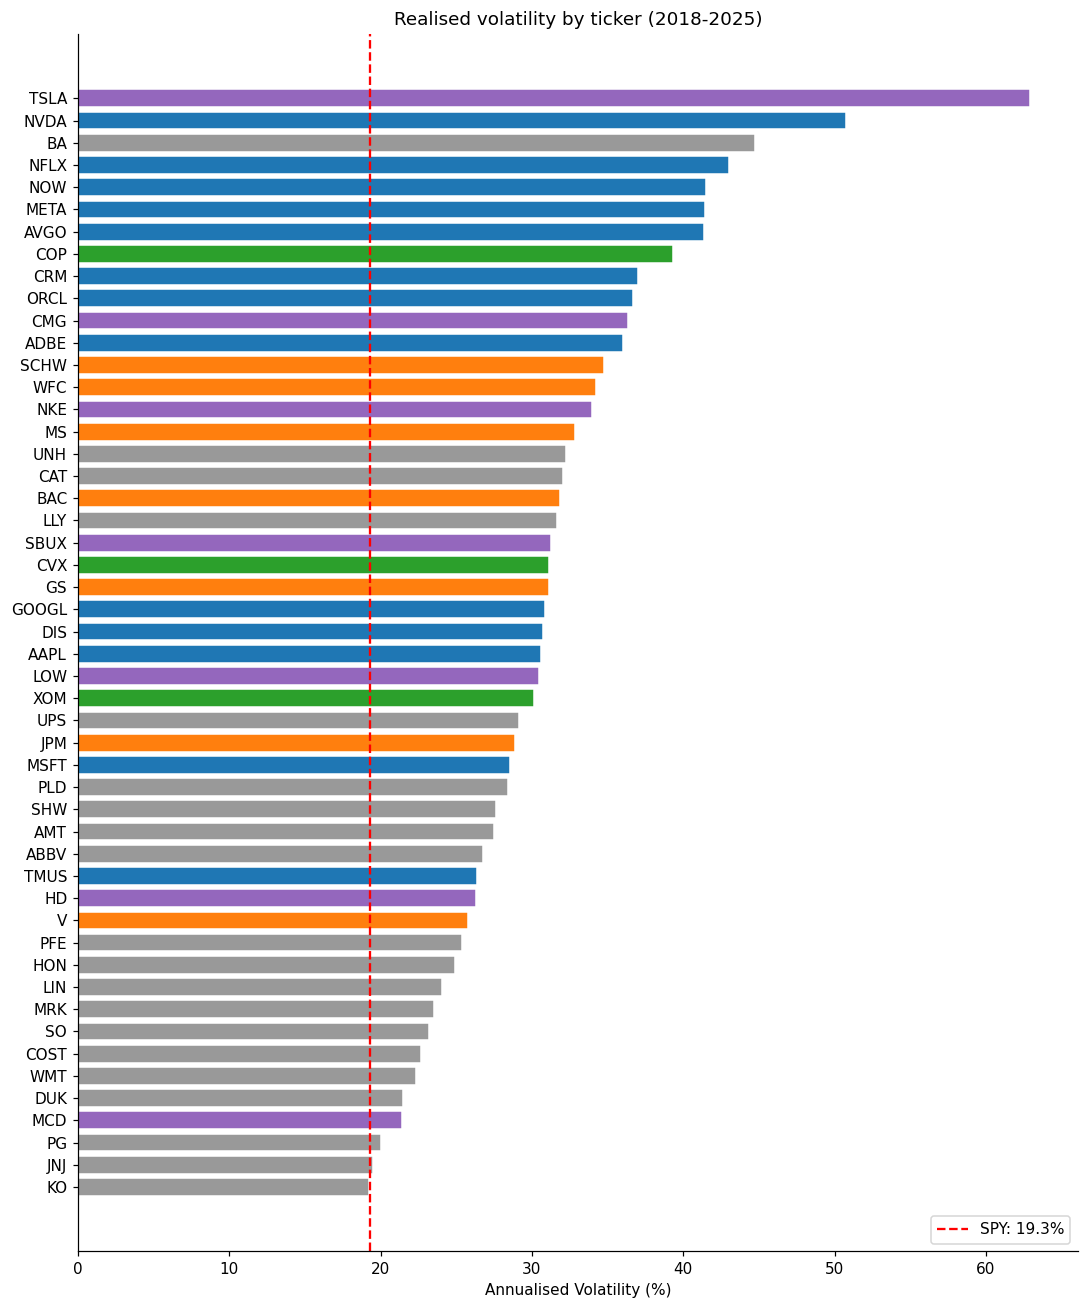

In [9]:
ret_d = pivot_px.pct_change().dropna()
ann_vol = ret_d.std() * np.sqrt(252) * 100
spy_vol = ann_vol.pop('SPY') if 'SPY' in ann_vol.index else None
vol_sorted = ann_vol.sort_values()

color_map = {'IT': '#1f77b4', 'Comm': '#1f77b4', 'Financial': '#ff7f0e',
             'Energy': '#2ca02c', 'Cons Disc': '#9467bd'}
colors_by_sec = [color_map.get(SECTOR_MAP.get(t, ''), '#999999') for t in vol_sorted.index]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(vol_sorted.index, vol_sorted.values, color=colors_by_sec, edgecolor='white')
if spy_vol is not None:
    ax.axvline(spy_vol, color='red', linestyle='--', linewidth=1.5, label=f'SPY: {spy_vol:.1f}%')
ax.set_xlabel('Annualised Volatility (%)')
ax.set_title('Realised volatility by ticker (2018-2025)')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 7. Event study — validating the 10-day label

If the label is meaningful, we should see a systematic price reaction around the call.
Average all ~1500 events aligned on T=0 and look at T-5 to T+15.

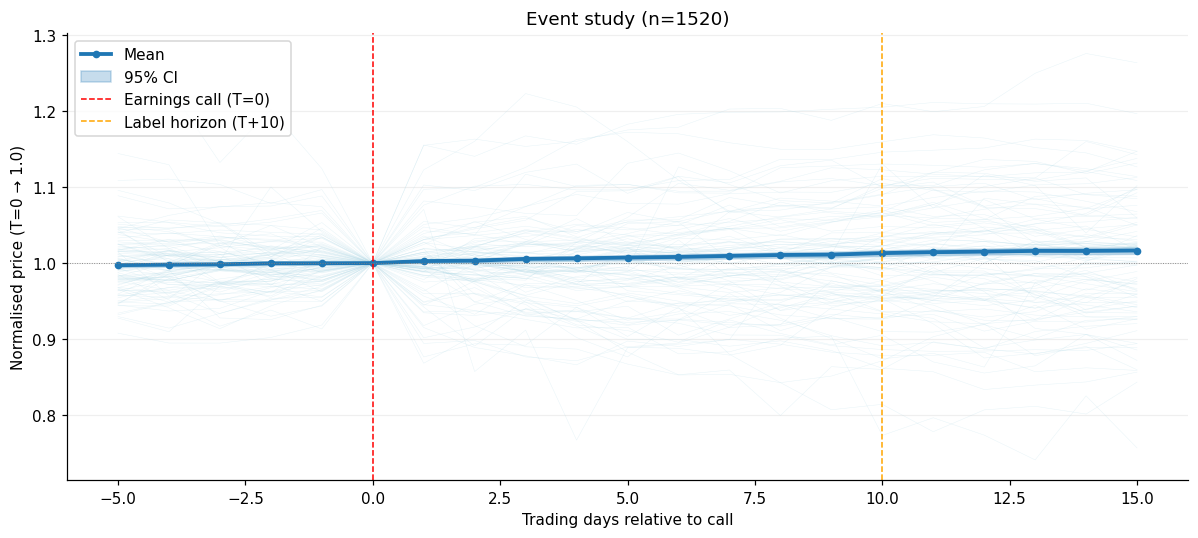


Average cum return T=0 to T+10: +1.31%


In [10]:
event_dates = labels[['ticker', 'event_date']].dropna().copy()

paths = []
for _, row in event_dates.iterrows():
    sub = prices[prices.ticker == row['ticker']].sort_values('date').reset_index(drop=True)
    mask = sub.date >= row['event_date']
    if not mask.any(): continue
    t0 = mask.idxmax()
    if t0 < 5 or t0 + 15 >= len(sub): continue
    win = sub.iloc[t0-5: t0+16][price_col].values
    if len(win) != 21 or win[5] == 0: continue
    paths.append(win / win[5])

paths = np.array(paths)
days = np.arange(-5, 16)
mean_path = paths.mean(axis=0)
sem = paths.std(axis=0) / np.sqrt(len(paths))

fig, ax = plt.subplots(figsize=(11, 5))
for p in paths[::15]:
    ax.plot(days, p, color='lightblue', linewidth=0.3, alpha=0.3)
ax.plot(days, mean_path, color='#1f77b4', linewidth=2.5, label='Mean', marker='o', markersize=4)
ax.fill_between(days, mean_path - 1.96*sem, mean_path + 1.96*sem,
                color='#1f77b4', alpha=0.25, label='95% CI')
ax.axvline(0,  color='red',    linestyle='--', linewidth=1, label='Earnings call (T=0)')
ax.axvline(10, color='orange', linestyle='--', linewidth=1, label='Label horizon (T+10)')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.6)
ax.set_xlabel('Trading days relative to call')
ax.set_ylabel('Normalised price (T=0 → 1.0)')
ax.set_title(f'Event study (n={len(paths)})')
ax.legend(loc='upper left'); ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()

print(f'\nAverage cum return T=0 to T+10: {(mean_path[15]-1)*100:+.2f}%')

Pre-call price ~ random walk; post-call drift to T+10 is the post-earnings
announcement drift (PEAD). Confirms the 10-day horizon captures real signal.

## 8. Naive equal-weight benchmark

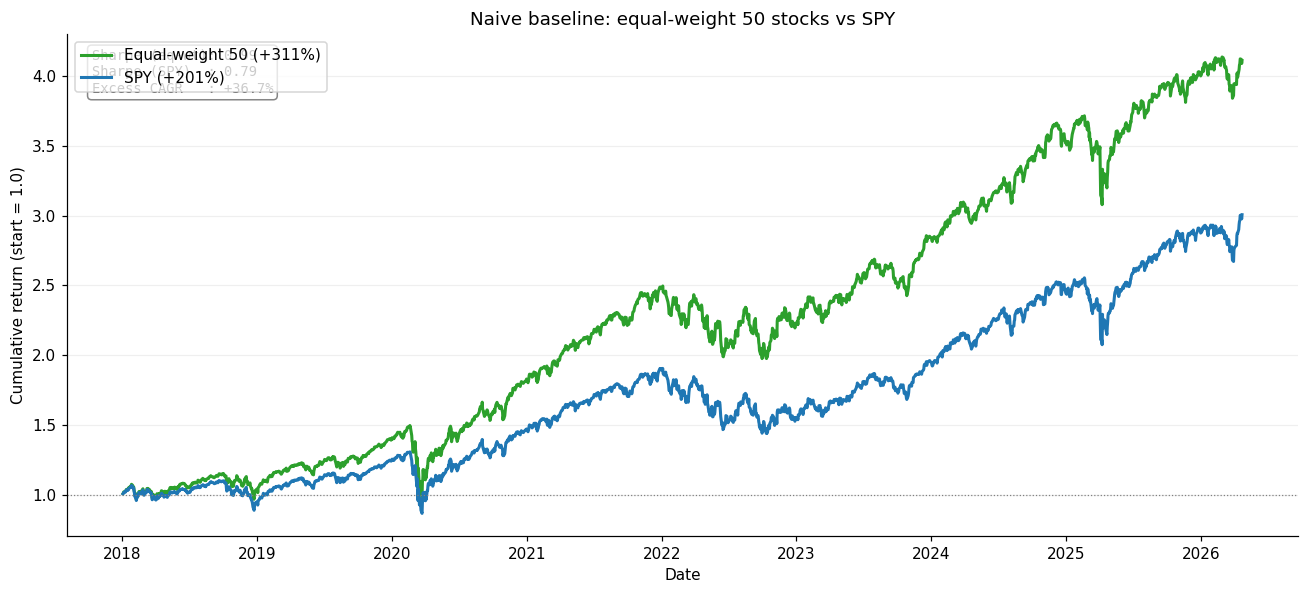

In [11]:
eq_w = ret_d.drop(columns='SPY', errors='ignore').mean(axis=1)
spy_r = ret_d['SPY']
eq_cum, spy_cum = (1 + eq_w).cumprod(), (1 + spy_r).cumprod()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(eq_cum.index, eq_cum, color='#2ca02c', linewidth=2,
        label=f'Equal-weight 50 ({eq_cum.iloc[-1] - 1:+.0%})')
ax.plot(spy_cum.index, spy_cum, color='#1f77b4', linewidth=2,
        label=f'SPY ({spy_cum.iloc[-1] - 1:+.0%})')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Date'); ax.set_ylabel('Cumulative return (start = 1.0)')
ax.set_title('Naive baseline: equal-weight 50 stocks vs SPY')
ax.legend(loc='upper left'); ax.grid(axis='y', alpha=0.2)

eq_sh  = eq_w.mean()  / eq_w.std()  * np.sqrt(252)
spy_sh = spy_r.mean() / spy_r.std() * np.sqrt(252)
ax.text(0.02, 0.97,
        f'Sharpe (eq-wt): {eq_sh:.2f}\nSharpe (SPY)  : {spy_sh:.2f}\n'
        f'Excess CAGR   : {(eq_cum.iloc[-1]/spy_cum.iloc[-1] - 1):+.1%}',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=9, family='monospace',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.95))
plt.tight_layout(); plt.show()

**Bar to clear.** Equal-weight already beats SPY by selecting established large caps.
Strategy C / D (LLM + CNN) must out-perform this, not just SPY.